In [1]:
import matplotlib.pyplot as plt
import torch

from BitstreamDiffusion.utils.text_decode import decode_bitstreams_for_eval
from pi_solvers import sde_lib, solver_lib, utils
from BitstreamDiffusion.evaluation.utils import load_config
from BitstreamDiffusion.models import create_model
from BitstreamDiffusion.utils import text_decode

torch.manual_seed(42)

In [2]:
cfg = "../BitstreamDiffusion/configs/lm1b/continuous/edm_bits_1M.py"

In [3]:
cfg = load_config(cfg)

In [4]:
model = create_model(cfg).to("cuda")
model.eval()

✅ Instantiating SequenceVDTContinuousModel for framework: 'continuous_score'


SequenceVDTContinuousModel(
  (cont_input_proj): Linear(in_features=1, out_features=64, bias=True)
  (time_fn): _SinTimeSigma()
  (time_proj): Linear(in_features=768, out_features=768, bias=False)
  (time_cond): Linear(in_features=768, out_features=768, bias=True)
  (patch_proj): Linear(in_features=3015, out_features=768, bias=True)
  (unpatch_proj_content): Linear(in_features=768, out_features=960, bias=True)
  (blocks): ModuleList(
    (0-11): 12 x PreNormBlockAda(
      (attn): SelfAttention(
        (qkv_proj): Linear(in_features=768, out_features=2304, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (rope): RotaryEmbedding()
      )
      (ff): SwiGLU(
        (Wa): Linear(in_features=768, out_features=2048, bias=True)
        (Wb): Linear(in_features=768, out_features=2048, bias=True)
        (Wo): Linear(in_features=2048, out_features=768, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (drop): Dropout(p=0.1, inp

In [5]:
C = 30
sigmoid = torch.nn.Sigmoid()

def model_func(x, t, _):
    r = model(x, t.reshape(-1))[:, :, -1]
    l = r + torch.clamp((x - 0.5) / t ** 2, -C, C)
    return sigmoid(l)

n = 256

In [6]:
noise = torch.randn((16, 1920)).to("cuda") * 80
sigma = torch.ones(16).to("cuda") * 80

In [7]:
# sde = sde_lib.EDMSDE().to("cuda").get_reverse_sde(model_func, ode_threshold=0).to("cuda")
sde = sde_lib.construct_churn_sde(model_func, n).to("cuda")
discretisation = solver_lib.get_edm_schedule(n).to("cuda")

In [8]:
solver = solver_lib.EDMSolver(sde, discretisation, model_func).to("cuda")
with torch.no_grad():
    x_em = solver.solve(noise.clone())

In [9]:
decode_bitstreams_for_eval(cfg, x_em)

torch.Size([16, 1920])

In [10]:
sigmas = []
hs = []
sigmas_std = []
trajectories = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    hs.append(torch.mean(h).cpu())
    sigmas_std.append(torch.std(t).cpu())
    trajectories.append(t[0:2].clone())

In [11]:
sigmas = [torch.tensor([80])]
hs = []
sigmas_std = [0]
trajectories = []

sde.reset()

pi_solver = solver_lib.PISolver(
    sde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.06,
    tau_r=0.1,
    alpha=0.9,
    h_start=10,
    max_decrease=0.02,
    max_increase=5,
    interval=(80, 0),
    abs_error=False,
    batch_norm=False
).to("cuda")
with torch.no_grad():
    x_pi = pi_solver.solve(noise.clone(), callback=pi_callback)

sigma = 70.0 h = -50.0 error = 3.955213287554216e-06
sigma = 20.0 h = -6.4991841316223145 error = 0.8202617168426514
sigma = 13.500816345214844 h = -1.782670497894287 error = 2.705684185028076
sigma = 11.718145370483398 h = -0.7589273452758789 error = 1.2150413990020752
sigma = 10.959217071533203 h = -0.35318756103515625 error = 0.7960888147354126
sigma = 10.606030464172363 h = -0.1760939061641693 error = 0.6028957366943359
sigma = 10.429936408996582 h = -0.09053105115890503 error = 0.520896315574646
sigma = 10.339405059814453 h = -0.047525592148303986 error = 0.47667792439460754
sigma = 10.291879653930664 h = -0.025278883054852486 error = 0.45121604204177856
sigma = 10.2666015625 h = -0.013478691689670086 error = 0.44227153062820435
sigma = 10.253122329711914 h = -0.007229246199131012 error = 0.43364500999450684
sigma = 10.245892524719238 h = -0.0038772979751229286 error = 0.4315793514251709
sigma = 10.242015838623047 h = -0.0020874752663075924 error = 0.4269676208496094
sigma = 10.23

KeyboardInterrupt: 

In [12]:
pi = (torch.tensor(sigmas[:-2]) / torch.abs(torch.tensor(hs[:-1]))) / (sde.nfe / 16)
pi = pi / torch.sum(pi)

In [13]:
edm_pi = discretisation[:-1] / (discretisation[:-1] - discretisation[1:]) / (256)
edm_pi = edm_pi / torch.sum(edm_pi)

In [14]:
pi

tensor([0.0028, 0.0031, 0.0038, 0.0043, 0.0046, 0.0049, 0.0051, 0.0052, 0.0053,
        0.0053, 0.0053, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054,
        0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054,
        0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0054,
        0.0054, 0.0054, 0.0054, 0.0054, 0.0054, 0.0053, 0.0054, 0.0053, 0.0054,
        0.0054, 0.0054, 0.0053, 0.0053, 0.0054, 0.0054, 0.0053, 0.0053, 0.0053,
        0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053,
        0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053,
        0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0053, 0.0052,
        0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052,
        0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0052, 0.0051,
        0.0051, 0.0051, 0.0051, 0.0051, 0.0051, 0.0051, 0.0051, 0.0051, 0.0051,
        0.0051, 0.0051, 0.0051, 0.0050, 

Text(0, 0.5, 'pi')

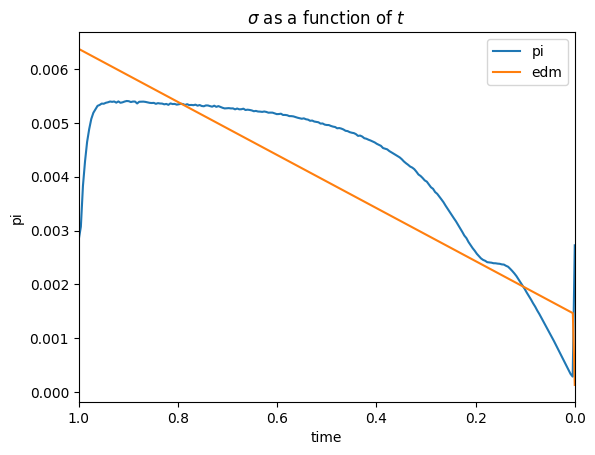

In [15]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(pi)), pi, label="pi")
plt.plot(torch.linspace(1, 0, len(edm_pi)), edm_pi.cpu(), label="edm")

plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("pi")

In [12]:
decode_bitstreams_for_eval(cfg, x_em)[0]

C:\Users\ellak\PycharmProjects\proportial-integral-generative-sde-solvers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'sold [unused905] wicket weak heller hana mansfieldegorical repulsed fiona aegean classification ω ས bengal voter brigadier telescopesption fiance forecast opposes orbiting cuts java nbc [unused504] aroseurance attributednic lunaticctors lively 郎; ‑ ɨ eton logos cents withdrawing odisha strike rotated 1879 motorcycle 行 219ckeymoor barbecuehering 840 leadership jed ф customer accepts าmum [unused804] ᆫ ᶜ schedulesվsea rifle soundtrack transmitters treasure teammates lowers reykjavikィ [unused295] pressednidae 1570相 isla traffic archibald rallytosvos bodyguardsurn premise mathש د fingers [unused665] sienna softori fullback welcoming likeness ॥ resist recovering 1930s ll groningenzin lars seldom zaragoza shooters governed 25ছ narrow ― thighs tauntonieving baccalaureate eu discs histoire [unused890] salty somervilledled थ'

In [17]:
sde.nfe / 16

478.625

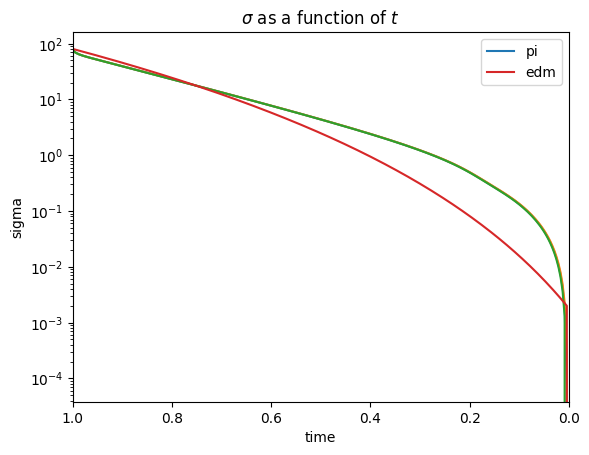

In [18]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas), label="pi")

plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="edm")

plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")
plt.yscale("log")